<a href="https://colab.research.google.com/github/prof-atritiack/1CC-MLAM-regressao-linear-CP2-2sem/blob/main/Exemplo_Aula_07_1CCPK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Exemplo de treinamento e avaliação de um modelo preditivo de regressão**

# Coluna alvo y (target) ---> 'stab' (numérica)
# Dados de entrada X (Features): precisam ser definidas com base na matriz de
# correlaçao entre a coluna alvo 'stab' e todas as demais colunas numéricas.
# Gere os gráficos de dispersão (scatter plot) entre 'stab' e as demais colunas.
# Após treinar o modelo, levante os gráficos de dispersão Real X Previsto
# com a reta de regressão

# Preparação do ambiente

In [1]:

import pandas as pd

# Ferramentas para Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Separação de dados de treinamento e teste
from sklearn.model_selection import train_test_split

# Algoritmo: Regressão Linear
from sklearn.linear_model import LinearRegression

# Avaliação dos modelos (MSE, R2, MAE)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#Carga dos dados

In [2]:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/1CC-SERS-CP2-2SEM/refs/heads/main/datasets/Data_for_UCI_named.csv')

# Análise Exploratória

In [3]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [5]:
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [6]:
# Estatística de colunas categóricas
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [ ]:
# Definição de dados de entrada (Features ou Variáveis Independentes)
# e dados de saída (Target ou Variável Dependente)
# X (maiúsculo) ----> entrada
# y (minúsculo) ----> saída

In [ ]:
# Quais são os atributos que tem maior correlação com atributo alvo (target)
# Monte uma matriz de correlação de todas as variáveis do dataframe 'dados'
# usando heatmap (possíveis features vs target)

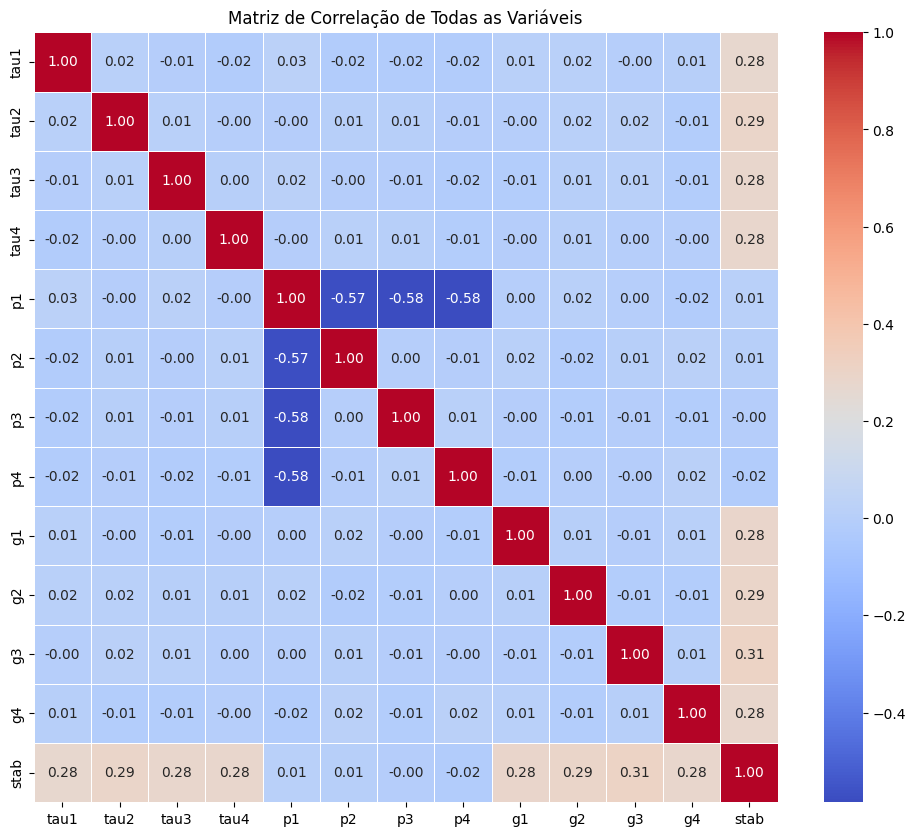

In [8]:
correlation_matrix = dados.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação de Todas as Variáveis')
plt.show()

In [9]:
# Os atributos (Top3) com maior correlação com a coluna alvo são: tau2, g2 e g3
# Features
X = dados[['tau2', 'g2', 'g3']]
X.head()

,tau2,g2,g3
0,3.079885,0.859578,0.887445
1,4.902524,0.862414,0.562139
2,8.848428,0.766689,0.839444
3,7.669600,0.976744,0.929381
4,7.608772,0.455450,0.656947


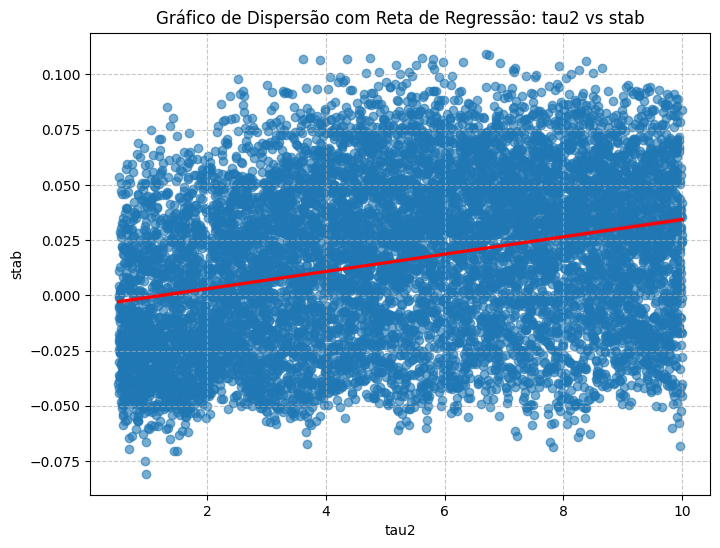

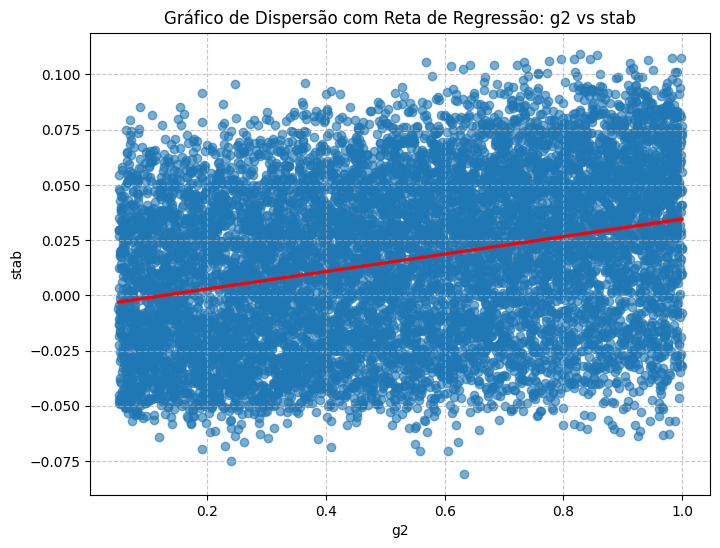

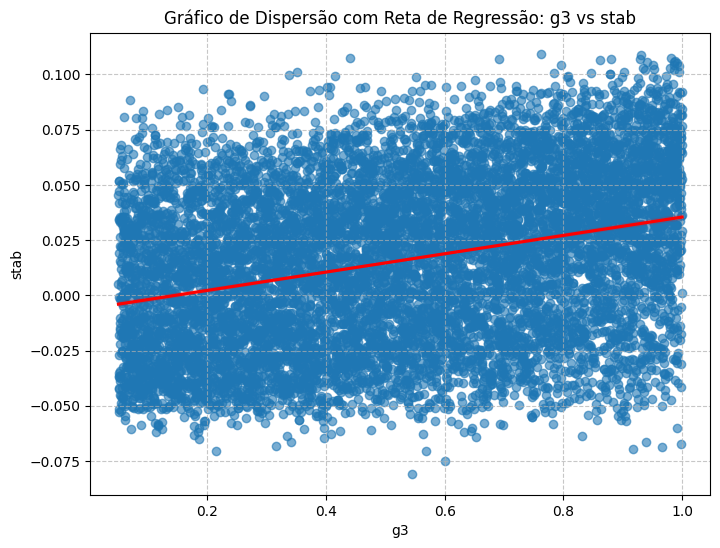

In [13]:
y = dados['stab']

# Gerar gráficos de dispersão de stab vs features (g2, g3 e tau2) com reta de regressão
for feature in X.columns:
    plt.figure(figsize=(8, 6))
    sns.regplot(x=dados[feature], y=y, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    plt.title(f'Gráfico de Dispersão com Reta de Regressão: {feature} vs stab')
    plt.xlabel(feature)
    plt.ylabel('stab')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

In [10]:
X.shape

(10000, 3)

In [7]:
y = dados['stab']
y

,stab
0,0.055347
1,-0.005957
2,0.003471
3,0.028871
4,0.049860
...,...
9995,0.023892
9996,-0.025803
9997,-0.031810
9998,0.037789


# Separação de dados de treinamento e teste

X_train, X_test, y_train, y_test

In [16]:
# SEED ---> random_state ---> parâmetro para "fixar" a amostra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9)

##MODELO DE REGRESSÃO LINEAR

In [14]:
modeloRL = LinearRegression()

In [17]:
modeloRL.fit(X_train, y_train)

LinearRegression()

In [19]:
y_predict = modeloRL.predict(X_test)
y_predict

array([0.01836467, 0.01212292, 0.01116957, ..., 0.00826269, 0.02235197,
       0.01997406])

In [21]:
# Métricas do modelo de regressão
mse = mean_squared_error(y_test, y_predict)
r2 = r2_score(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
print(f'MSE: {mse:.3f}')
print(f'R2: {r2:.3f}')
print(f'MAE: {mae:.3f}')

MSE: 0.001
R2: 0.244
MAE: 0.026


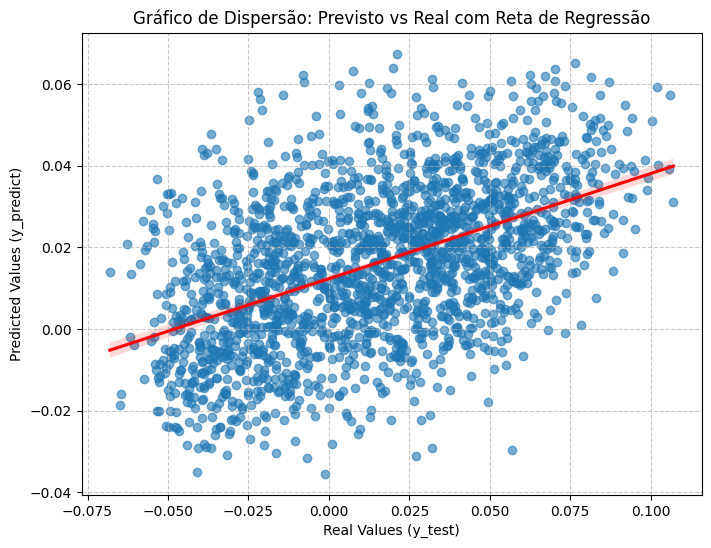

In [24]:
# Gerar gráfico de dispersão Previsto vs Real com reta de regressão
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_predict, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Gráfico de Dispersão: Previsto vs Real com Reta de Regressão')
plt.xlabel('Real Values (y_test)')
plt.ylabel('Predicted Values (y_predict)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()